# STEP 06 — Deep Q-Network (DQN) with PyTorch

A tabular Q-Learning után ugyanazt a `Q(s,a)` gondolatot neurális hálóval approximáljuk. Ez a notebook **nem rejti el a működést egy library mögé**: külön megnézzük a Q-networköt, replay buffert, Bellman targetet és target networköt, majd ténylegesen tanítunk egy kis PyTorch DQN-t.

In [1]:
from pathlib import Path
import sys, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

ROOT = Path.cwd()
if ROOT.name == "workflow":
    ROOT = ROOT.parent
SRC = ROOT / "src"
for p in [ROOT, SRC]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from workflow.shared.utils import ensure_data, load_config, build_env

cfg = load_config()
full, train, val, test = ensure_data()
FIG_DIR = ROOT / "04_results" / "figures"
METRIC_DIR = ROOT / "04_results" / "metrics"
MODEL_DIR = ROOT / "04_results" / "models"
PRED_DIR = ROOT / "04_results" / "predictions"
for p in [FIG_DIR, METRIC_DIR, MODEL_DIR, PRED_DIR]:
    p.mkdir(parents=True, exist_ok=True)

QUICK_MODE = True  # GitHub notebookhoz gyors futás. Komolyabb benchmarkhoz állítsd False-ra.
SEEDS = [42, 123, 2026]
print(f"Project root: {ROOT}")
print(f"Rows: full={len(full):,}, train={len(train):,}, validation={len(val):,}, test={len(test):,}")

Project root: /mnt/data/smart_battery_energy_management_rl
Rows: full=8,760, train=6,132, validation=1,314, test=1,314


## 1. Miért kell DQN?

Tabular Q-Learningnél minden diszkrét state külön Q-vektort kap. DQN-nél a neurális háló hasonló state-ek között képes generalizálni: a bemenet a folytonos observation vector, a kimenet pedig a három action Q-értéke.

In [2]:
import torch
from battery_rl.agents.dqn_torch import QNetwork, ReplayBuffer, TorchDQNAgent, train_dqn
from battery_rl.evaluation import evaluate_policy

env = build_env(train, cfg, random_start=True)
net = QNetwork(observation_dim=len(env.obs_columns), action_dim=3)
print(net)
print("Trainable parameters:", sum(p.numel() for p in net.parameters() if p.requires_grad))

QNetwork(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=3, bias=True)
  )
)
Trainable parameters: 17667


## 2. Egy forward pass

A háló kimenete nem probability. Három becsült Q-értéket ad: charge, idle, discharge.

In [3]:
obs, _ = env.reset(seed=42)
with torch.no_grad():
    q = net(torch.tensor(obs, dtype=torch.float32).unsqueeze(0)).squeeze(0)
pd.DataFrame({"action":["charge","idle","discharge"], "initial_Q":q.numpy()})

,action,initial_Q
0,charge,-0.124832
1,idle,-0.076104
2,discharge,-0.136585


## 3. Experience Replay

A környezet egymást követő transitionjei erősen korreláltak. A replay buffer eltárolja `(s, a, r, s', done)` mintákat, majd random minibatch-eket vesz belőlük. Így a gradient update kevésbé követi vakon az időrendi korrelációt.

In [4]:
buffer = ReplayBuffer(capacity=100, seed=42)
obs, _ = env.reset(seed=42)
for _ in range(12):
    action = env.action_space.sample()
    next_obs, reward, terminated, truncated, _ = env.step(action)
    buffer.add(obs, action, reward, next_obs, terminated or truncated)
    obs = next_obs
    if terminated or truncated:
        obs, _ = env.reset(seed=42)
print("Transitions in replay buffer:", len(buffer))
batch = buffer.sample(batch_size=4, device=torch.device("cpu"))
print("obs batch shape:", batch[0].shape, "actions shape:", batch[1].shape)

Transitions in replay buffer: 12
obs batch shape: torch.Size([4, 5]) actions shape: torch.Size([4, 1])


## 4. Bellman target egy konkrét minibatch példán

`target = r + γ (1-done) max_a Q_target(s',a)`

A target network azért külön háló, hogy a célérték ne ugyanazzal a gradient update-tel mozogjon, mint az online Q-network.

In [5]:
online = QNetwork(len(env.obs_columns), 3)
target = QNetwork(len(env.obs_columns), 3)
target.load_state_dict(online.state_dict())
obs_b, act_b, rew_b, next_b, done_b = batch
with torch.no_grad():
    next_q = target(next_b).max(dim=1, keepdim=True).values
    bellman_target = rew_b + 0.97 * (1-done_b) * next_q
q_sa = online(obs_b).gather(1, act_b)
pd.DataFrame({"Q_online(s,a)": q_sa.detach().squeeze().numpy(), "Bellman_target": bellman_target.squeeze().numpy()})

,"Q_online(s,a)",Bellman_target
0,0.011096,-4.795750
1,-0.159910,-8.299100
2,0.014389,-7.337706
3,-0.003673,-12.877039


## 5. DQN training

A notebook QUICK_MODE-ban néhány ezer environment stepet futtat, hogy GitHubon és lokálisan gyorsan újrafuttatható legyen. A `config.yaml` teljes futáshoz nagyobb timestepszámot tartalmaz.

In [6]:
dcfg = cfg["dqn"]
steps = 2500 if QUICK_MODE else int(dcfg["timesteps"])
dqn = TorchDQNAgent(
    observation_dim=len(env.obs_columns),
    learning_rate=dcfg["learning_rate"], gamma=dcfg["gamma"],
    buffer_size=dcfg["buffer_size"], batch_size=dcfg["batch_size"],
    target_update_interval=dcfg["target_update_interval"],
    epsilon_start=dcfg["epsilon_start"], epsilon_end=dcfg["epsilon_end"],
    epsilon_decay_steps=min(dcfg["epsilon_decay_steps"], steps), seed=42,
)
history = train_dqn(env, dqn, total_steps=steps, learning_starts=min(300, steps//5), seed=42)
dqn.save(MODEL_DIR / "dqn_torch_seed_42.pt")
print("Finished episodes:", len(history.episode_returns), "gradient updates:", len(history.losses))

Finished episodes: 104 gradient updates: 2200


## 6. Episode return training curve

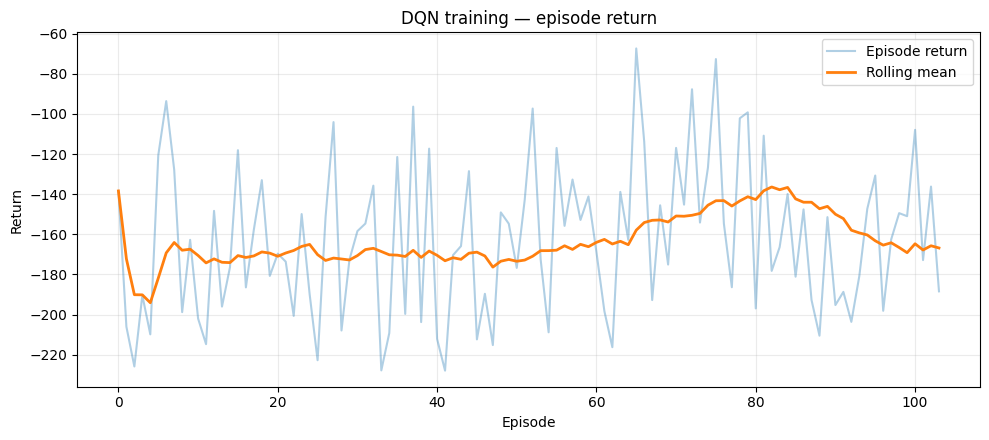

In [7]:
returns = pd.Series(history.episode_returns)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(returns, alpha=0.35, label="Episode return")
ax.plot(returns.rolling(20, min_periods=1).mean(), linewidth=2, label="Rolling mean")
ax.set_title("DQN training — episode return")
ax.set_xlabel("Episode"); ax.set_ylabel("Return"); ax.legend(); ax.grid(alpha=0.25)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb06_01_dqn_return.png", dpi=170, bbox_inches="tight")
plt.show()

## 7. Training loss

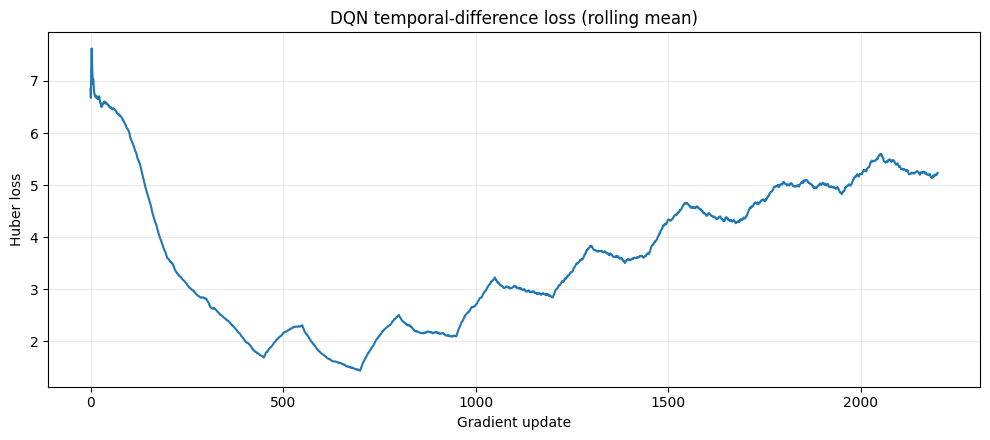

In [8]:
losses = pd.Series(history.losses)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(losses.rolling(100, min_periods=1).mean())
ax.set_title("DQN temporal-difference loss (rolling mean)")
ax.set_xlabel("Gradient update"); ax.set_ylabel("Huber loss"); ax.grid(alpha=0.25)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb06_02_dqn_loss.png", dpi=170, bbox_inches="tight")
plt.show()

## 8. Epsilon schedule a tényleges training során

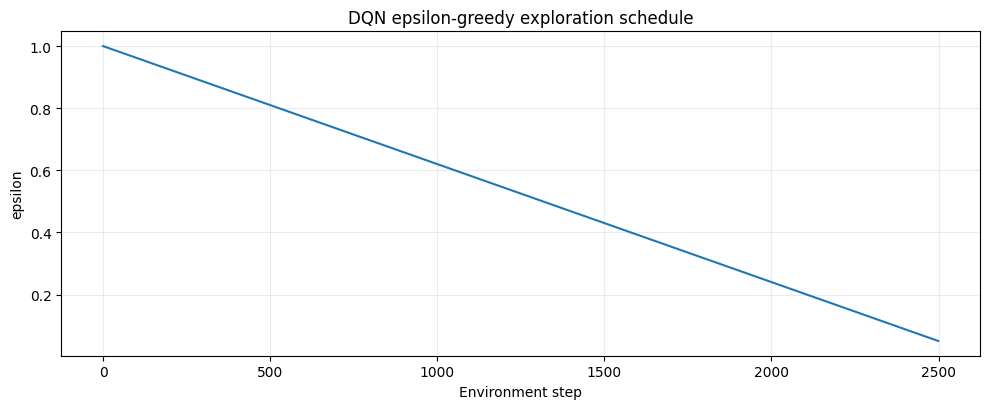

In [9]:
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(history.epsilons)
ax.set_title("DQN epsilon-greedy exploration schedule")
ax.set_xlabel("Environment step"); ax.set_ylabel("epsilon"); ax.grid(alpha=0.25)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb06_03_dqn_epsilon.png", dpi=170, bbox_inches="tight")
plt.show()

## 9. Mean predicted Q-value

Ez diagnosztikai görbe. Ha a Q-értékek kontrollálatlanul elszállnak, az instabil tanulás jele lehet.

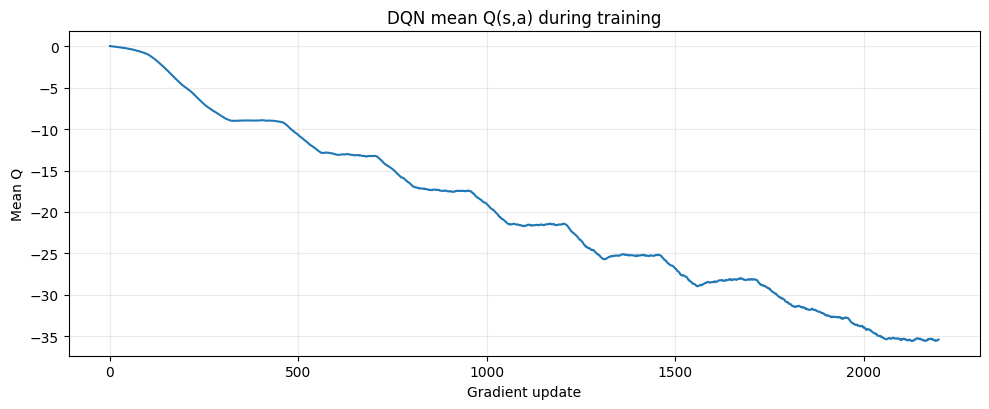

In [10]:
qmean = pd.Series(history.q_values)
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(qmean.rolling(100, min_periods=1).mean())
ax.set_title("DQN mean Q(s,a) during training")
ax.set_xlabel("Gradient update"); ax.set_ylabel("Mean Q"); ax.grid(alpha=0.25)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb06_04_dqn_q_values.png", dpi=170, bbox_inches="tight")
plt.show()

## 10. Validation és test KPI-k

In [11]:
val_metrics, _ = evaluate_policy(lambda: build_env(val, cfg, random_start=True), dqn, seeds=SEEDS, episodes=6 if QUICK_MODE else 20)
test_metrics, dqn_logs = evaluate_policy(lambda: build_env(test, cfg, random_start=True), dqn, seeds=SEEDS, episodes=6 if QUICK_MODE else 20)
dqn_summary = pd.DataFrame({"validation_mean":val_metrics.mean(numeric_only=True), "test_mean":test_metrics.mean(numeric_only=True), "test_std":test_metrics.std(numeric_only=True)})
display(dqn_summary)
val_metrics.to_csv(METRIC_DIR / "step06_dqn_validation_metrics.csv", index=False)
test_metrics.to_csv(METRIC_DIR / "step06_dqn_test_metrics.csv", index=False)
dqn_logs.to_csv(PRED_DIR / "step06_dqn_seed_42_logs.csv", index=False)

,validation_mean,test_mean,test_std
total_electricity_cost,123.459436,95.826206,20.044728
peak_grid_demand_kw,67.953318,65.583327,6.463706
renewable_self_consumption_pct,96.014240,79.515651,4.387487
battery_throughput_kwh,98.789474,78.250000,46.980581
battery_cycles,0.411623,0.326042,0.195752
constraint_violations,1.333333,1.166667,0.408248
average_soc,0.175283,0.171998,0.122713
cumulative_reward,-125.353629,-97.613078,19.287247
episode_return,-125.353629,-97.613078,19.287247


## 11. DQN representative episode

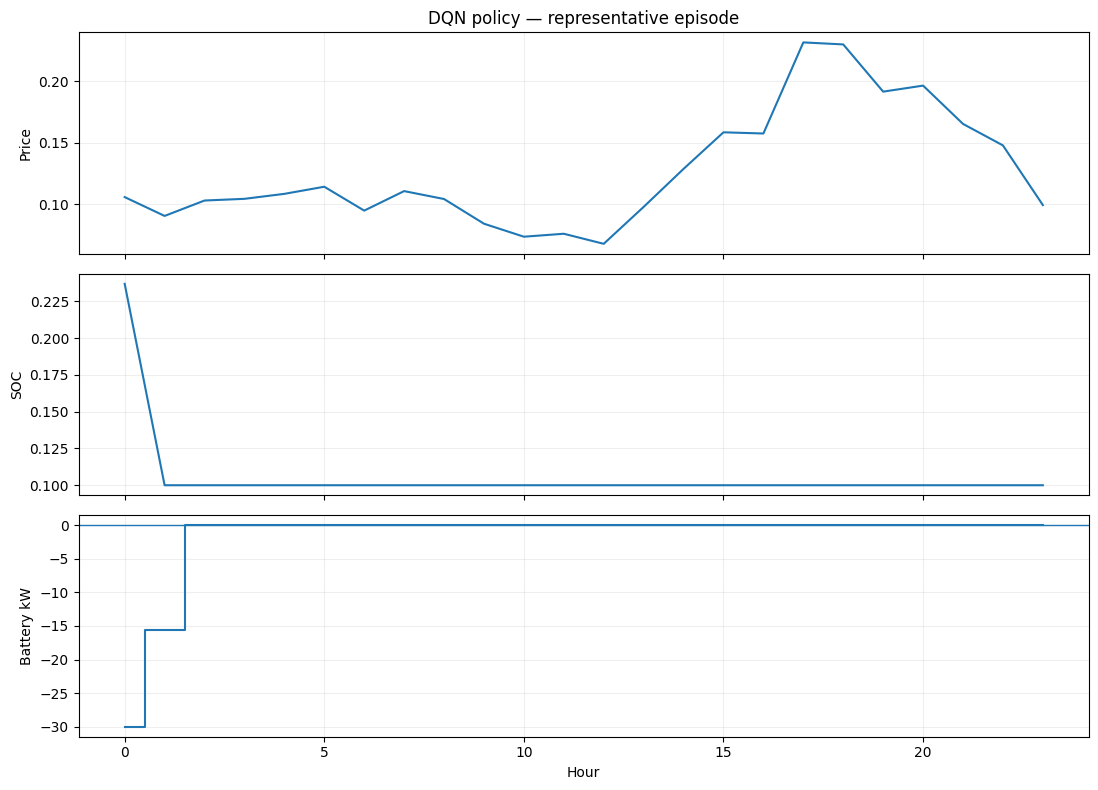

In [12]:
episode0 = dqn_logs[dqn_logs.episode == 0].copy()
x = np.arange(len(episode0))
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
axes[0].plot(x, episode0.price); axes[0].set_ylabel("Price")
axes[1].plot(x, episode0.soc); axes[1].set_ylabel("SOC")
axes[2].step(x, episode0.executed_battery_power_kw, where="mid"); axes[2].axhline(0, linewidth=1); axes[2].set_ylabel("Battery kW"); axes[2].set_xlabel("Hour")
for ax in axes: ax.grid(alpha=0.2)
axes[0].set_title("DQN policy — representative episode")
fig.tight_layout(); fig.savefig(FIG_DIR / "nb06_05_dqn_episode.png", dpi=170, bbox_inches="tight")
plt.show()

## Mit adott a DQN a tabular Q-Learninghez képest?

A DQN megszünteti a kézzel definiált state-bin táblát, és folytonos observationből tanul approximált Q-függvényt. Cserébe megjelennek új stabilitási kérdések: replay buffer méret, target update gyakoriság, learning rate, network capacity és Q-value drift.

A projektben ezért a DQN-t **nem csak final costtal**, hanem loss/Q/exploration diagnosztikával is vizsgáljuk.